# Employee Attrition Analytics & Explainable Attrition Prediction

## Notebook 10: Model Explainability using SHAP

### Objective

The objective of this notebook is to explain how the selected machine learning model makes predictions using SHAP (SHapley Additive exPlanations). Both global and local explanations are generated to identify the key factors influencing employee attrition and translate these insights into meaningful HR recommendations.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

The required libraries are imported to load the trained model, generate SHAP explanations, visualize feature contributions, and interpret model predictions.

# Load the Best Performing Model

The best-performing model selected in Notebook 9 is loaded for explainability analysis. Only the final deployed model is interpreted to ensure consistency between evaluation and deployment.

In [2]:
best_model = joblib.load("../models/best_model.pkl")

print(type(best_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


# Load the Test Dataset

The unseen test dataset is loaded to explain predictions on data that was not used during model training. This provides a realistic understanding of the model's decision-making process.

In [3]:
X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv").squeeze()

In [4]:
print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

X_test Shape : (294, 59)
y_test Shape : (294,)


The shapes of the testing datasets are verified to ensure they match the data used during model evaluation.

# Generate Predictions

Predictions and prediction probabilities are generated again using the selected model. These outputs will later be compared with SHAP explanations to understand why the model makes specific decisions.

In [5]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [6]:
print("First Five Predictions:")
print(y_pred[:5])

print("\nFirst Five Prediction Probabilities:")
print(y_prob[:5])


First Five Predictions:
[0 0 0 0 0]

First Five Prediction Probabilities:
[1.06677784e-154 1.30964497e-082 0.00000000e+000 0.00000000e+000
 2.28914039e-100]


# What is SHAP?

SHAP (SHapley Additive exPlanations) is an Explainable AI technique based on cooperative game theory. It assigns each feature a contribution value that indicates how much it increases or decreases the prediction for an individual observation.

Unlike traditional feature importance methods, SHAP explains both overall model behavior (global explainability) and individual predictions (local explainability), making machine learning models more transparent and easier to interpret.

# Initialize SHAP Explainer

The selected model is a Logistic Regression classifier, which is a linear model. Therefore, SHAP's `LinearExplainer` is used to efficiently compute the contribution of each feature to the model's predictions.

In [7]:
explainer = shap.LinearExplainer(best_model, X_test)

The SHAP explainer has been initialized successfully and is ready to compute feature contribution values for each employee in the testing dataset.

In [8]:
shap_values = explainer.shap_values(X_test)

In [9]:
print("X_test Shape:", X_test.shape)
print("SHAP Values Shape:", shap_values.shape)

X_test Shape: (294, 59)
SHAP Values Shape: (294, 59)


# Global Model Explainability

Global explainability helps identify the features that have the greatest overall influence on employee attrition predictions across the entire dataset.

In this section, SHAP visualizations are used to understand which factors most strongly increase or decrease the predicted risk of employee attrition.

## SHAP Summary Plot

The SHAP Summary Plot visualizes the contribution of every feature across all employees.

Features are ranked according to their overall importance, while the color indicates the feature value (high or low). This plot helps identify the variables that most strongly influence attrition predictions.

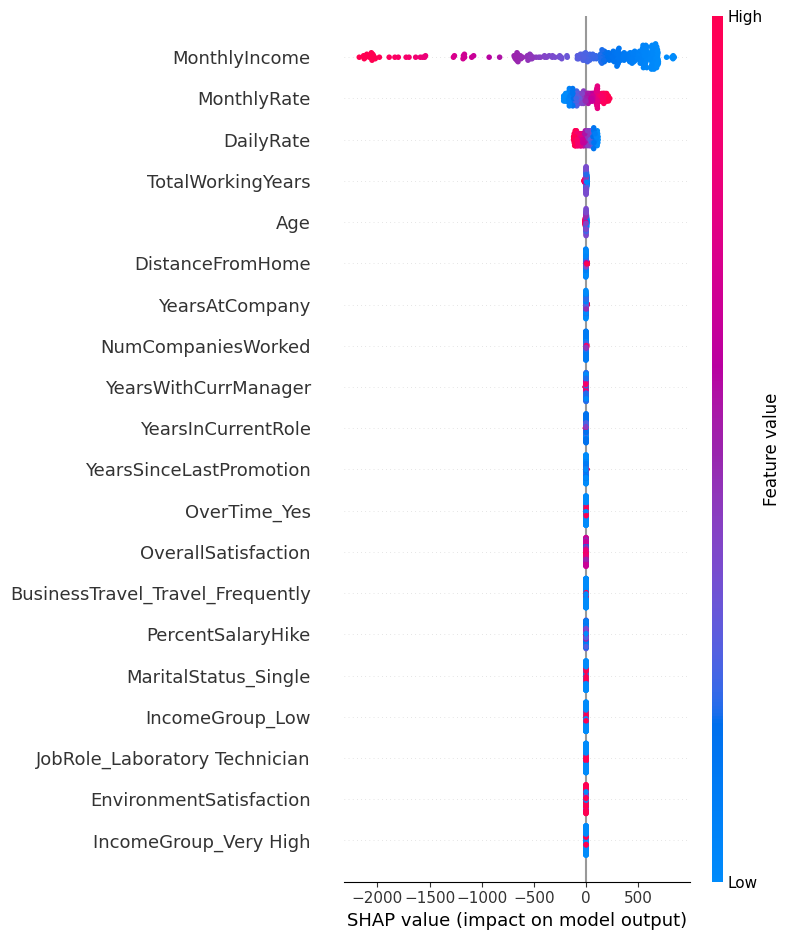

In [10]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

### Observation

The SHAP Summary Plot highlights the most influential features affecting employee attrition predictions.

Features appearing near the top have the greatest impact on the model's decisions. Positive SHAP values increase the likelihood of attrition, while negative SHAP values reduce it. The distribution of points also illustrates how feature values influence prediction outcomes across different employees.

## SHAP Feature Importance Bar Plot

The SHAP Bar Plot ranks features according to their average absolute SHAP values.

Unlike the Summary Plot, this visualization focuses only on the overall importance of each feature, making it easier to communicate key drivers of employee attrition to non-technical stakeholders.

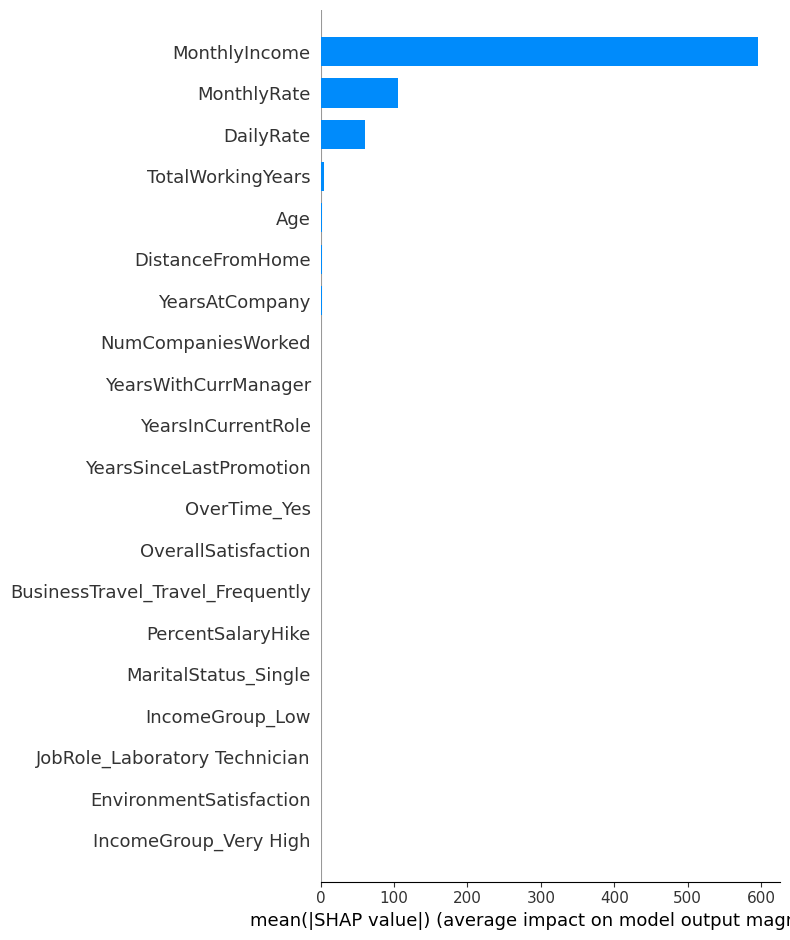

In [11]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

### Observation

The SHAP Bar Plot ranks the features according to their average contribution to the model's predictions.

Features with larger average SHAP values have a greater overall influence on attrition predictions. This provides a simple and intuitive view of feature importance that can be easily interpreted by HR professionals and business stakeholders.

## Compare SHAP Importance with Logistic Regression Coefficients

Logistic Regression coefficients indicate the direction and strength of the relationship between each feature and the predicted outcome.

SHAP values, on the other hand, measure the actual contribution of each feature to individual predictions. Comparing both helps validate the model's behavior and improves interpretability.

In [12]:
coef_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Coefficient": best_model.coef_[0]
})

coef_df["AbsoluteCoefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="AbsoluteCoefficient",
    ascending=False
)

coef_df.head(10)

,Feature,Coefficient,AbsoluteCoefficient
44,OverTime_Yes,1.833646,1.833646
24,BusinessTravel_Travel_Frequently,1.526533,1.526533
35,JobRole_Laboratory Technician,1.127991,1.127991
38,JobRole_Research Director,-0.966432,0.966432
43,MaritalStatus_Single,0.840682,0.840682
45,IncomeGroup_Low,0.791298,0.791298
31,EducationField_Other,-0.769135,0.769135
47,IncomeGroup_Very High,0.748961,0.748961
16,TotalWorkingYears,-0.677477,0.677477
25,BusinessTravel_Travel_Rarely,0.660814,0.660814


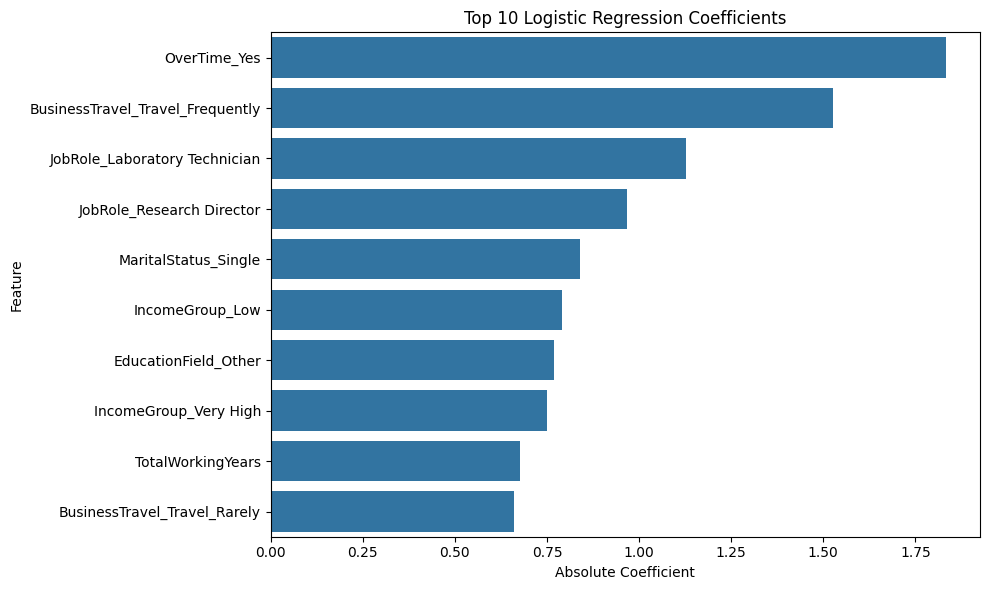

In [13]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=coef_df.head(10),
    x="AbsoluteCoefficient",
    y="Feature"
)

plt.title("Top 10 Logistic Regression Coefficients")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Observation

The Logistic Regression coefficients indicate which features have the strongest linear relationship with employee attrition.

Comparing these coefficients with SHAP feature importance helps verify whether the model's learned relationships align with the feature contributions observed across the dataset. While coefficients describe the model mathematically, SHAP provides a more intuitive explanation of how each feature influences individual predictions.

# Local Model Explainability

While global explainability identifies the most influential features across the entire dataset, local explainability explains why the model made a specific prediction for an individual employee.

In this section, SHAP Waterfall Plots are used to visualize how different features contribute to the predicted attrition risk for selected employees.

## Employee 1 – High Attrition Risk

The first employee selected has one of the highest predicted probabilities of attrition. The SHAP Waterfall Plot explains which features increased or decreased the employee's predicted attrition risk.

In [14]:
high_risk_index = np.argmax(y_prob)

print("Employee Index:", high_risk_index)
print("Predicted Attrition Probability:", y_prob[high_risk_index])

Employee Index: 199
Predicted Attrition Probability: 0.9999999999999996


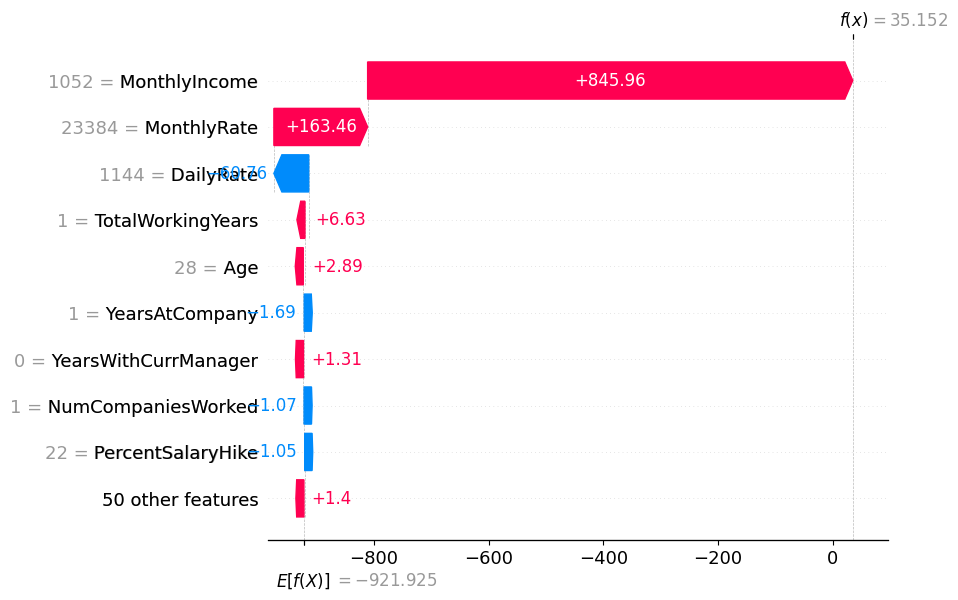

In [15]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_index],
        feature_names=X_test.columns
    )
)

### Observation

The Waterfall Plot shows how individual features contributed to the prediction for this employee.

Features pushing the prediction to the right increase the likelihood of attrition, while features pushing to the left reduce attrition risk. Together, these feature contributions explain the model's final prediction.

## Employee 2 – Low Attrition Risk

The second employee selected has one of the lowest predicted probabilities of attrition. This helps understand which factors contributed to the employee being classified as likely to stay.

In [16]:
low_risk_index = np.argmin(y_prob)

print("Employee Index:", low_risk_index)
print("Predicted Attrition Probability:", y_prob[low_risk_index])

Employee Index: 2
Predicted Attrition Probability: 0.0


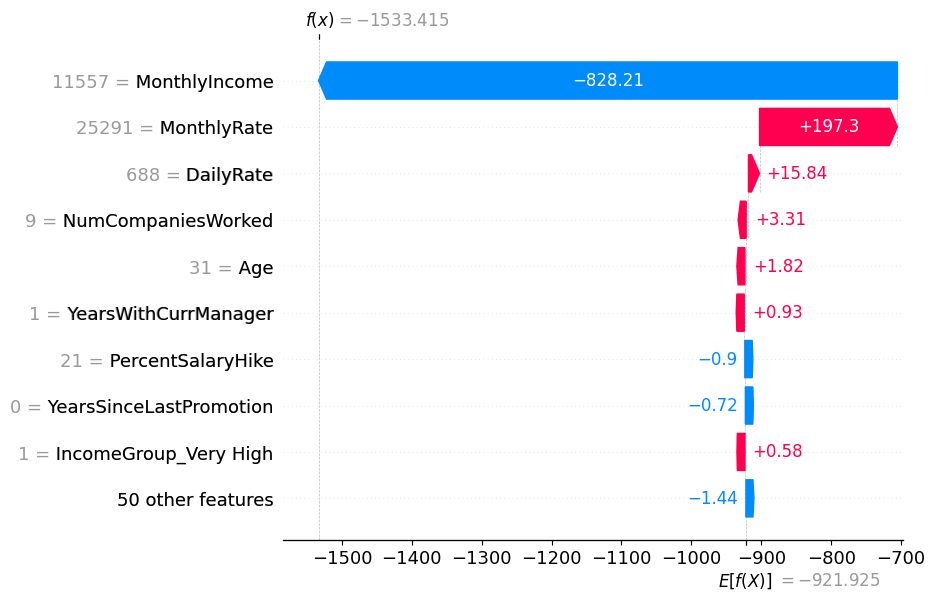

In [17]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_risk_index],
        feature_names=X_test.columns
    )
)

### Observation

For this employee, several features contributed to reducing the predicted attrition risk.

The combined effect of these feature contributions resulted in a low probability of attrition, indicating that the employee is likely to remain with the organization.

## Employee 3 – Moderate Attrition Risk

The third employee selected has a prediction probability close to the classification threshold. Such borderline cases are useful for understanding how relatively small changes in feature values can influence the model's final decision.

In [18]:
borderline_index = np.argmin(np.abs(y_prob - 0.5))

print("Employee Index:", borderline_index)
print("Predicted Attrition Probability:", y_prob[borderline_index])

Employee Index: 246
Predicted Attrition Probability: 4.0385031397697053e-07


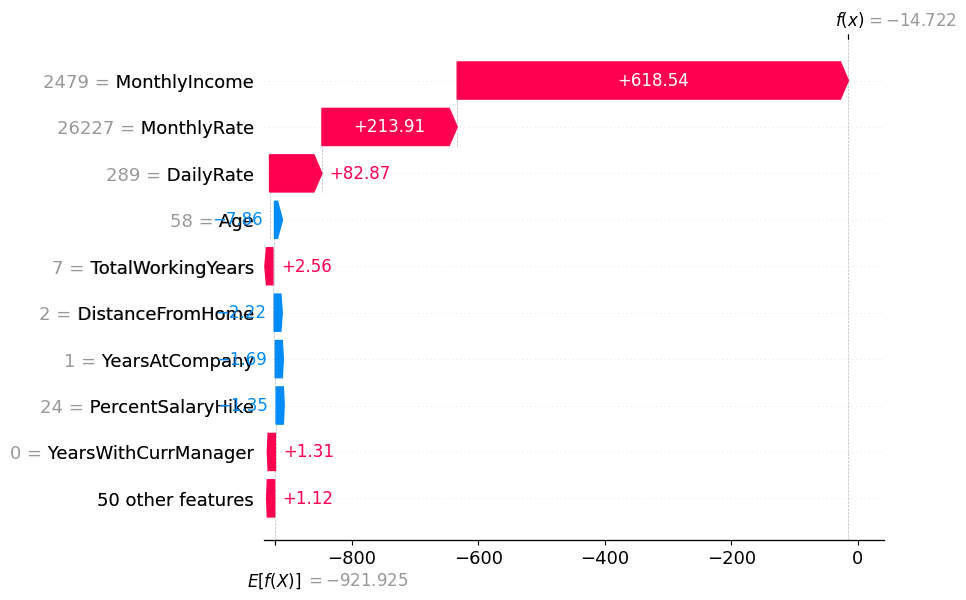

In [19]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[borderline_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[borderline_index],
        feature_names=X_test.columns
    )
)

### Observation

The prediction for this employee lies close to the decision boundary, indicating that both positive and negative feature contributions are relatively balanced.

Borderline cases highlight how multiple factors interact to influence the final prediction and demonstrate the importance of considering individual employee characteristics rather than relying on a single feature.

# Business Interpretation of SHAP Explanations

SHAP values explain how different employee characteristics influence the model's predictions. However, these technical explanations must be translated into business insights that HR professionals can understand and act upon.

This section interprets the model's findings in the context of employee retention and workforce management.

## Understanding SHAP in HR Context

Rather than focusing on SHAP values alone, the emphasis is placed on understanding how employee characteristics influence attrition risk.

Features with positive SHAP values increase the predicted likelihood of employee attrition, while negative SHAP values reduce the predicted risk. This enables HR teams to identify the factors that contribute most to employee turnover.

## Comparison of High-Risk and Low-Risk Employees

The SHAP analysis demonstrates that employees with high predicted attrition probabilities typically have multiple risk factors acting together, whereas employees with low attrition probabilities generally benefit from several protective factors.

This comparison highlights that employee attrition is influenced by a combination of characteristics rather than a single feature.

### Business Observation

High-risk employees generally exhibit stronger positive feature contributions that increase attrition probability, whereas low-risk employees show stronger negative contributions that reduce attrition risk.

This demonstrates that employee retention depends on the combined influence of multiple workplace factors rather than any individual variable.

# HR Recommendations

Based on the SHAP analysis, several practical recommendations can help reduce employee attrition and improve workforce retention.

### Recommendation 1: Manage Employee Workload

If overtime consistently increases attrition risk, HR should monitor employee workloads, encourage work-life balance, and reduce excessive overtime whenever possible.

### Recommendation 2: Improve Career Growth Opportunities

Employees experiencing long promotion delays may perceive limited career advancement opportunities.

Regular promotion reviews, internal mobility programs, and transparent career progression can improve employee retention.

### Recommendation 3: Improve Employee Satisfaction

Lower levels of job satisfaction or work-life balance may increase the likelihood of employee attrition.

Regular employee feedback, engagement surveys, recognition programs, and flexible work policies can improve overall satisfaction.

### Recommendation 4: Review Compensation Policies

If lower income contributes to higher attrition risk, HR should periodically review salary structures, incentive programs, and employee benefits to remain competitive within the industry.

### Recommendation 5: Identify High-Risk Employees Early

The predictive model can be used as an early warning system to identify employees who are at greater risk of leaving.

This enables HR teams to proactively implement personalized retention strategies before employees decide to resign.

# What-If Analysis

One advantage of SHAP is that it allows decision-makers to understand how changes in employee characteristics may influence predicted attrition risk.

For example, reducing overtime, improving job satisfaction, or providing timely promotions could potentially lower an employee's predicted likelihood of leaving.

Although these changes do not guarantee different outcomes, they provide valuable guidance for designing effective employee retention strategies.

# Save Explainability Visualizations

The generated explainability visualizations are saved for documentation, reporting, and future use in the Streamlit application.

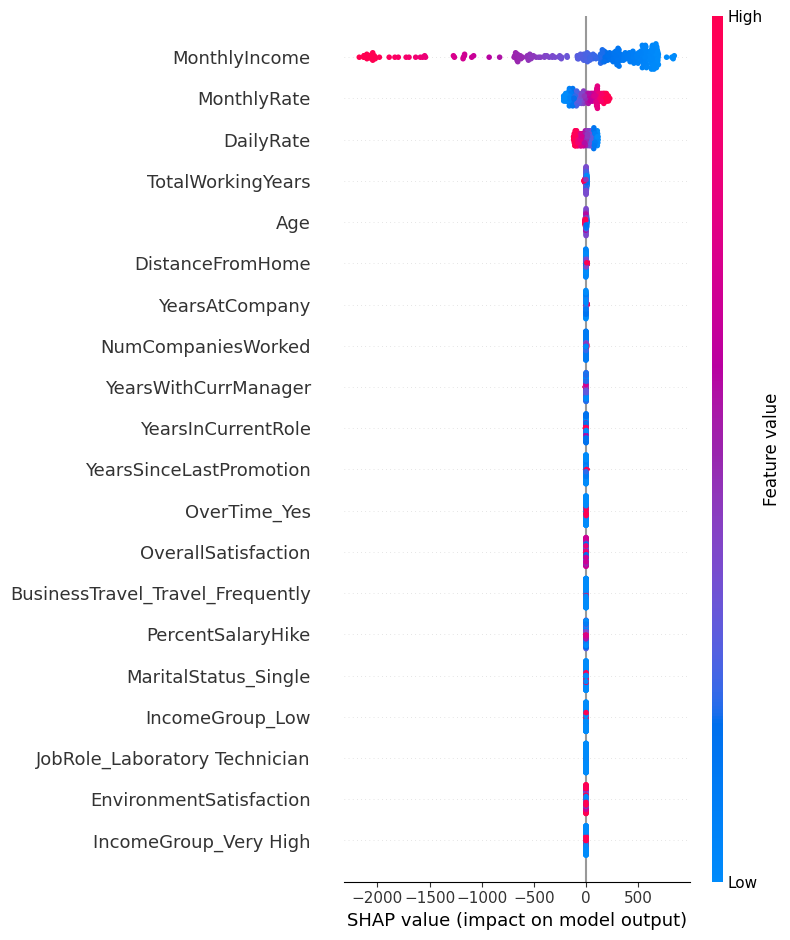

In [20]:
# SHAP Summary Plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig("../images/shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

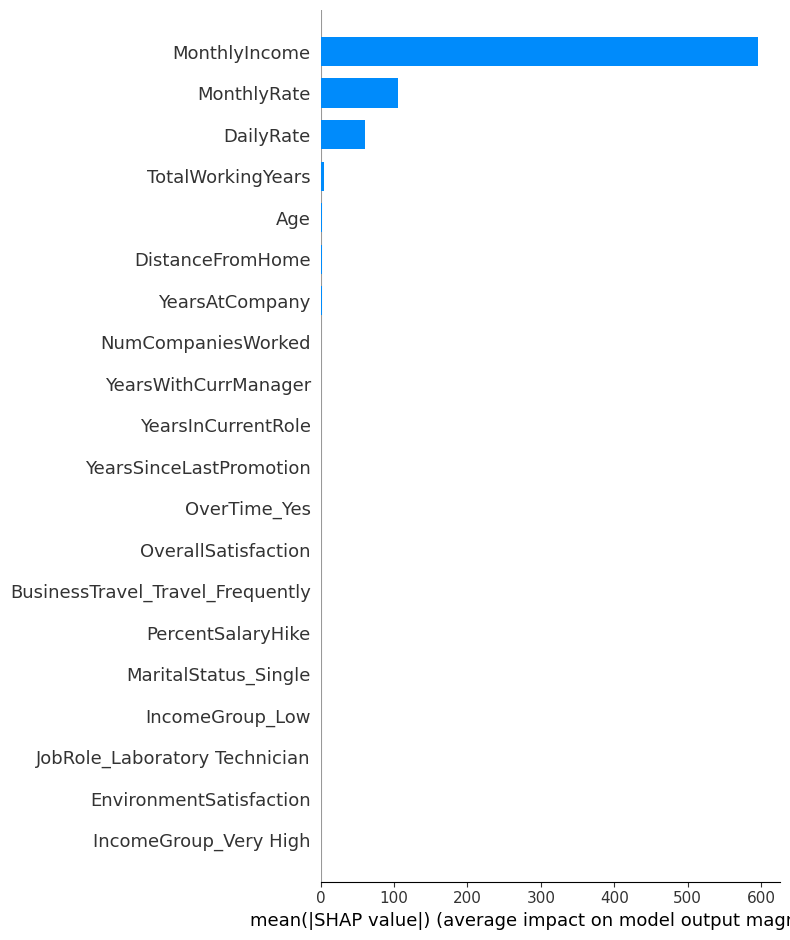

In [21]:
# SHAP Feature Importance Bar Plot

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../images/shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

The most important global explainability visualizations have been saved successfully and can be used in reports, presentations, and deployment.

# Save Waterfall Plots

Waterfall plots explain the prediction for individual employees by showing how each feature contributes to the final prediction.

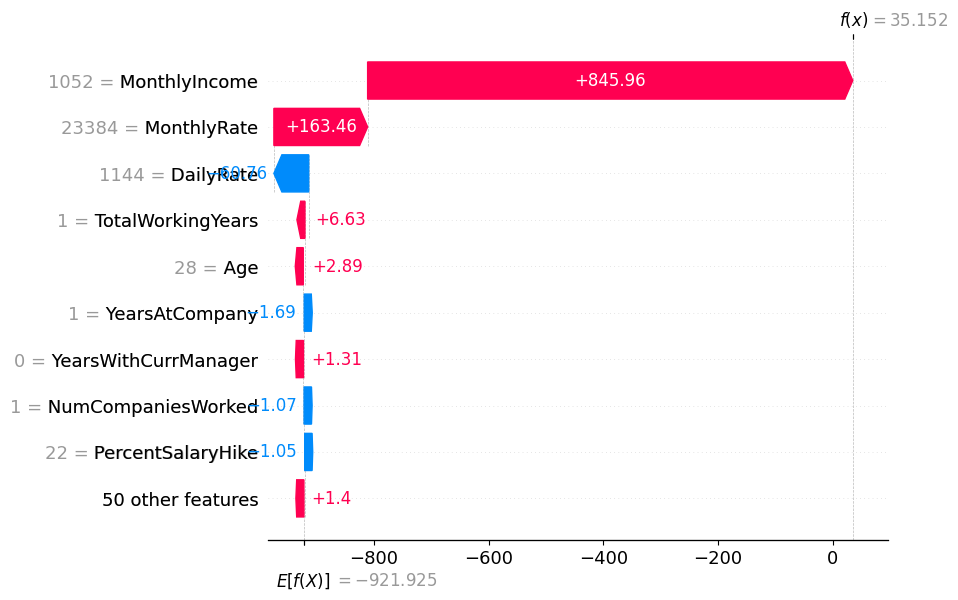

In [22]:
# High-risk employee

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[high_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_index],
        feature_names=X_test.columns
    ),
    show=False
)

plt.savefig(
    "../images/waterfall_high_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

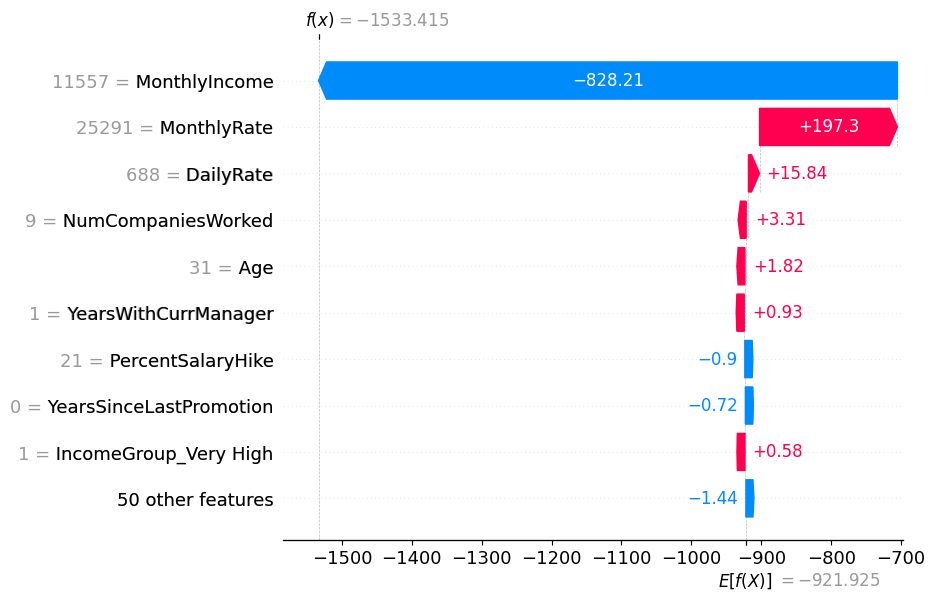

In [23]:
# Low-risk employee

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[low_risk_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_risk_index],
        feature_names=X_test.columns
    ),
    show=False
)

plt.savefig(
    "../images/waterfall_low_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

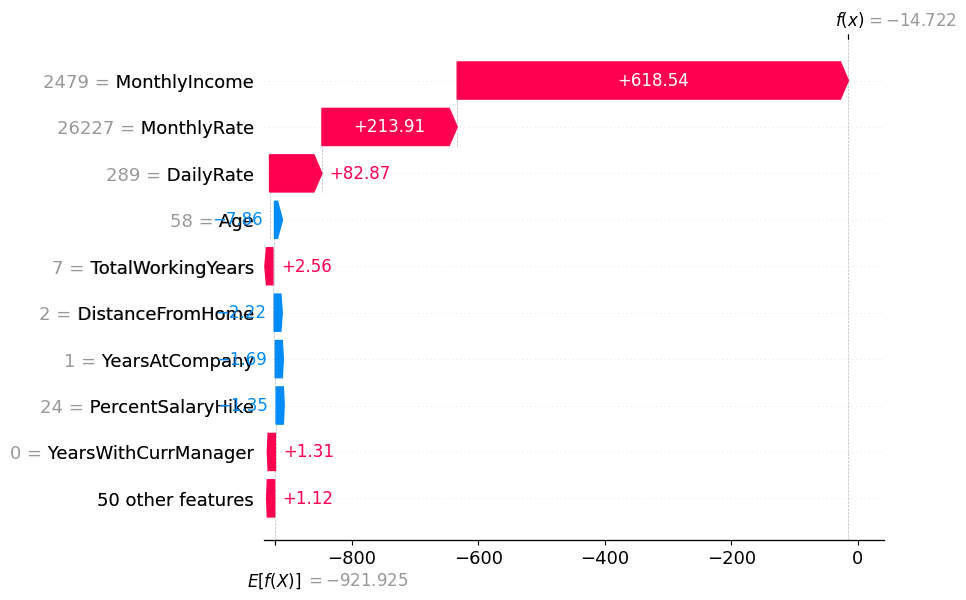

In [24]:
# Borderline employee

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[borderline_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[borderline_index],
        feature_names=X_test.columns
    ),
    show=False
)

plt.savefig(
    "../images/waterfall_borderline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The individual SHAP Waterfall Plots have been saved successfully and can be used to explain specific employee predictions in a transparent and interpretable manner.

# Notebook Summary

In this notebook, Explainable Artificial Intelligence (XAI) techniques were applied to understand how the selected Logistic Regression model predicts employee attrition.

SHAP was used to generate both global and local explanations, making the model more transparent and easier to interpret. The analysis identified the most influential features affecting attrition predictions and demonstrated how individual employee characteristics contribute to the final prediction.

The insights obtained from SHAP were translated into practical HR recommendations, showing how explainable machine learning can support evidence-based decision-making for employee retention.

# Key Takeaways

- Successfully loaded and explained the selected Logistic Regression model using SHAP.
- Generated SHAP values for every employee in the testing dataset.
- Identified the most influential features affecting employee attrition.
- Explained individual employee predictions using SHAP Waterfall Plots.
- Translated technical explanations into meaningful HR insights.
- Proposed actionable recommendations to support employee retention strategies.
- Saved explainability visualizations for documentation and future deployment.